# COVID-19 Weekly Case Forecasting Zimbabwe

**Author:** Bervely Pangwana
**Dataset:** Our World in Data COVID-19 Dataset (via Kaggle)

This notebook forecasts weekly COVID-19 case counts for Zimbabwe using two
different approaches a classic statistical time-series model (ARIMA) and a
machine learning approach (Random Forest with lag features) and compares
their performance.

**Note:** This is a technical forecasting exercise using historical public
health data. It is not intended for clinical or policy decision-making.


## 1. Setup

pip install statsmodels scikit-learn pandas matplotlib --break-system-packages
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

## 2. Load and Filter Data


In [3]:
df_raw = pd.read_csv("owid-covid-data.csv")  

df_zim = df_raw[df_raw["location"] == "Zimbabwe"][["date", "new_cases"]].copy()
df_zim["date"] = pd.to_datetime(df_zim["date"])
df_zim = df_zim.sort_values("date").set_index("date")

print("Shape:", df_zim.shape)
df_zim.head()

Shape: (716, 1)


,new_cases
date,
2020-03-20,1.0
2020-03-21,2.0
2020-03-22,0.0
2020-03-23,0.0
2020-03-24,0.0


In [5]:
# Fill missing daily values with 0, and clip any negative values
df_zim["new_cases"] = df_zim["new_cases"].fillna(0).clip(lower=0)

df_zim.tail()

,new_cases
date,
2022-03-01,491.0
2022-03-02,632.0
2022-03-03,0.0
2022-03-04,1236.0
2022-03-05,280.0


## 3. Resample to Weekly

Daily case data is noisy (reporting gaps, weekend dips). Resampling to
**weekly totals** smooths this out and gives a cleaner signal to forecast.

In [7]:
weekly = df_zim["new_cases"].resample("W").sum()

# Drop leading weeks with no reported cases yet (before the outbreak reached Zimbabwe)
weekly = weekly[weekly.index >= weekly[weekly > 0].index.min()]

print("Weekly series length:", len(weekly))
weekly.head()

Weekly series length: 103


date
2020-03-22     3.0
2020-03-29     4.0
2020-04-05     2.0
2020-04-12     5.0
2020-04-19    11.0
Freq: W-SUN, Name: new_cases, dtype: float64

## 4. Exploratory Plot

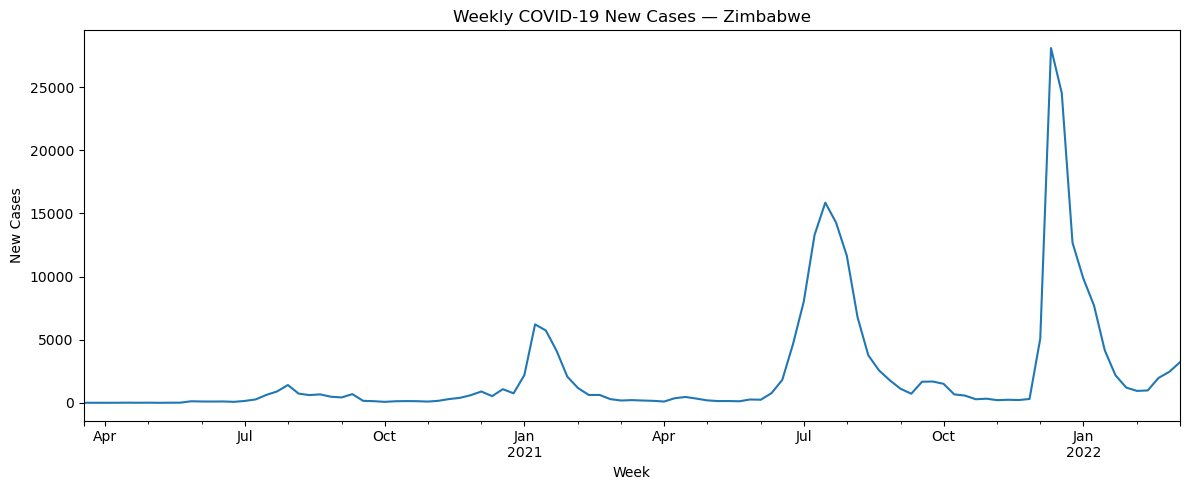

In [9]:
plt.figure(figsize=(12, 5))
weekly.plot()
plt.title("Weekly COVID-19 New Cases — Zimbabwe")
plt.ylabel("New Cases")
plt.xlabel("Week")
plt.tight_layout()
plt.savefig("weekly_cases.png")
plt.show()

## 5. Train/Test Split

We hold out the **last 12 weeks** as a test set the model never sees this
data during training, so evaluating against it tells us how well the model
would have predicted genuinely unseen future weeks.

In [11]:
test_size = 12
train = weekly.iloc[:-test_size]
test = weekly.iloc[-test_size:]

print(f"Train: {len(train)} weeks, Test: {len(test)} weeks")

Train: 91 weeks, Test: 12 weeks


## 6. Baseline Model: Naive Forecast

Before trusting any complex model, we need a baseline to beat. The simplest
possible forecast is "next week = same as last known week." If our real
models can't outperform this, they're not adding value.

In [13]:
naive_forecast = [train.iloc[-1]] * test_size

naive_mae = mean_absolute_error(test, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))

print(f"Naive baseline — MAE: {naive_mae:.2f}, RMSE: {naive_rmse:.2f}")

Naive baseline — MAE: 22104.08, RMSE: 23089.22


## 7. Model 1: ARIMA

First, check whether the series is stationary (constant mean/variance over
time) using the Augmented Dickey-Fuller test ARIMA assumes stationarity,
and the "I" (Integrated/differencing) term corrects for it if not.

In [15]:
adf_result = adfuller(train)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("Series is likely stationary (reject null hypothesis)")
else:
    print("Series is likely non-stationary — differencing (d=1 or higher) needed")

ADF Statistic: 0.0366
p-value: 0.9615
Series is likely non-stationary — differencing (d=1 or higher) needed


In [17]:
# Simple grid search over (p, d, q) combinations, selecting the model with lowest AIC
# (AIC balances model fit against complexity — lower is better)
best_aic = np.inf
best_order = None

for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            try:
                model = ARIMA(train, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except Exception:
                continue

print(f"Best ARIMA order: {best_order} (AIC: {best_aic:.2f})")

Best ARIMA order: (2, 1, 0) (AIC: 1630.95)


In [19]:
arima_model = ARIMA(train, order=best_order).fit()
arima_forecast = arima_model.forecast(steps=test_size)

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print(f"ARIMA{best_order} — MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")

ARIMA(2, 1, 0) — MAE: 258297.08, RMSE: 280190.38


## 8. Model 2: Random Forest with Lag Features

Here we reframe forecasting as a supervised learning problem: predict this
week's cases using the previous few weeks' values as input features.

In [21]:
def make_features(series, n_lags=4):
    df_feat = pd.DataFrame({"y": series})
    for lag in range(1, n_lags + 1):
        df_feat[f"lag_{lag}"] = series.shift(lag)
    df_feat["rolling_mean_3"] = series.shift(1).rolling(3).mean()
    return df_feat.dropna()

n_lags = 4
feat_df = make_features(weekly, n_lags=n_lags)

train_feat = feat_df.iloc[:-test_size]
X_train_rf = train_feat.drop(columns="y")
y_train_rf = train_feat["y"]

rf_model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest trained on", len(X_train_rf), "samples")

Random Forest trained on 87 samples


**Recursive forecasting:** since we don't know the actual case counts during
the test period (that would defeat the purpose of forecasting), we predict
one week at a time and feed each prediction back in as input for the next
week's lag features.

In [23]:
history = list(weekly.iloc[:-test_size])
rf_predictions = []

for i in range(test_size):
    feat_row = {}
    for lag in range(1, n_lags + 1):
        feat_row[f"lag_{lag}"] = history[-lag]
    feat_row["rolling_mean_3"] = np.mean(history[-3:])
    X_pred = pd.DataFrame([feat_row])[X_train_rf.columns]
    pred = rf_model.predict(X_pred)[0]
    rf_predictions.append(pred)
    history.append(pred)

rf_mae = mean_absolute_error(test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(test, rf_predictions))

print(f"Random Forest — MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

Random Forest — MAE: 6598.15, RMSE: 7358.76


## 9. Compare All Models

In [25]:
results = pd.DataFrame({
    "Model": ["Naive Baseline", f"ARIMA{best_order}", "Random Forest"],
    "MAE": [naive_mae, arima_mae, rf_mae],
    "RMSE": [naive_rmse, arima_rmse, rf_rmse],
}).sort_values("RMSE")

results

,Model,MAE,RMSE
2,Random Forest,6598.148139,7358.755482
0,Naive Baseline,22104.083333,23089.215832
1,"ARIMA(2, 1, 0)",258297.082207,280190.383296


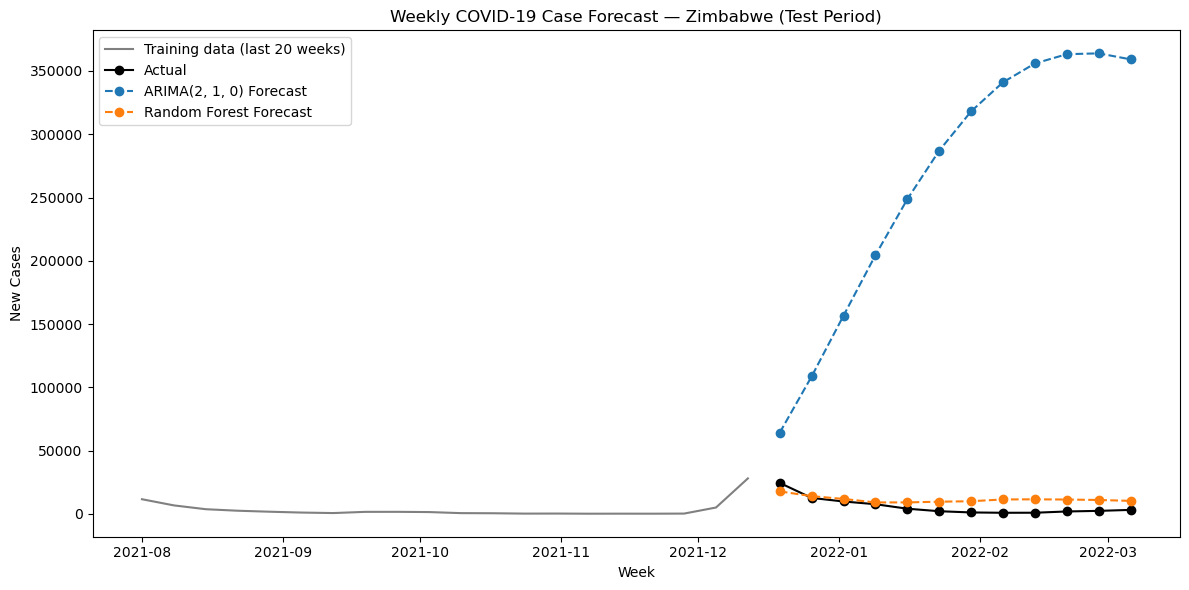

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(train.index[-20:], train.values[-20:], label="Training data (last 20 weeks)", color="gray")
plt.plot(test.index, test.values, label="Actual", color="black", marker="o")
plt.plot(test.index, arima_forecast, label=f"ARIMA{best_order} Forecast", linestyle="--", marker="o")
plt.plot(test.index, rf_predictions, label="Random Forest Forecast", linestyle="--", marker="o")
plt.title("Weekly COVID-19 Case Forecast — Zimbabwe (Test Period)")
plt.ylabel("New Cases")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.savefig("forecast_comparison.png")
plt.show()

## 10. Key Findings

**Data:** Weekly COVID-19 new case counts for Zimbabwe (March 2020 - March 2022), showing three distinct waves, with the largest (Omicron) peaking at ~28,000 weekly cases in December 2021 before crashing sharply by February 2022.

**Model Performance (12-week test period, which happened to span the Omicron wave peak and decline):**

| Model | MAE | RMSE |
|---|---|---|
| Random Forest | 6,598 | 7,359 |
| Naive Baseline | 22,104 | 23,089 |
| ARIMA(2,1,0) | 258,297 | 280,190 |

**Random Forest substantially outperformed both the naive baseline and ARIMA**, reducing error by ~70% versus the naive approach.

**Why ARIMA failed dramatically:** The test period began during a steep upward climb in cases (the start of the Omicron wave). ARIMA's linear autoregressive structure extrapolated that upward momentum and continued predicting exponential growth (forecasts exceeded 350,000 weekly cases), while actual cases peaked and sharply reversed. This highlights a key limitation of classic ARIMA models: they assume recent trends continue and cannot anticipate nonlinear turning points, which are common in epidemic waves.

**Why Random Forest performed better:** Having already seen two earlier wave-shaped cycles in the training data, the lag-feature-based model could better recognize wave patterns, even though it still lagged behind the speed of the actual decline. This suggests that for volatile, cyclical data like epidemic case counts, models capable of learning nonlinear patterns from historical analogues can meaningfully outperform classic linear time-series methods.

**Practical implication:** In a real forecasting deployment, this result would argue for either (a) using ensemble/ML approaches over pure ARIMA for epidemic data, or (b) using ARIMA only with careful monitoring and human override during periods of rapid trend change, rather than trusting it blindly during a wave's onset.
